In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

df = pd.read_parquet("/rhome/sawale/indus_traning/sentense_transformers/gen_data_stage3/filtered_sde_data/")

df.head()

,id,url1,title,text,n_words,url2,predicted,prob_included
0,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/data/,ACTIVATE: Data – NASA Langley Research Center...,ACTIVATE: Data - NASA Langley Research Center ...,3975,b'/ACTIVATE/data/',1,0.989475
1,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/,ACTIVATE: Home – NASA Langley Research Center ...,ACTIVATE: Home - NASA Langley Research Center ...,4659,b'/ACTIVATE/',1,0.990293
2,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/media/,ACTIVATE: Media – NASA Langley Research Cente...,ACTIVATE: Media - NASA Langley Research Center...,4458,b'/ACTIVATE/media/',1,0.985873
3,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/instrum...,ACTIVATE: Instruments – NASA Langley Research ...,ACTIVATE: Instruments - NASA Langley Research ...,4126,b'/ACTIVATE/instruments/',1,0.991540
4,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/education/,ACTIVATE: Education – NASA Langley Research C...,ACTIVATE: Education - NASA Langley Research Ce...,4192,b'/ACTIVATE/education/',1,0.992481


In [3]:
df.shape

(331083, 8)

In [4]:
# getting data that is not cmr or pds

df[~((df["id"].str.startswith("/SDE/CMR_API/")) | (df["id"].str.startswith("/SDE/PDS_API")))]

,id,url1,title,text,n_words,url2,predicted,prob_included
0,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/data/,ACTIVATE: Data – NASA Langley Research Center...,ACTIVATE: Data - NASA Langley Research Center ...,3975,b'/ACTIVATE/data/',1,0.989475
1,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/,ACTIVATE: Home – NASA Langley Research Center ...,ACTIVATE: Home - NASA Langley Research Center ...,4659,b'/ACTIVATE/',1,0.990293
2,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/media/,ACTIVATE: Media – NASA Langley Research Cente...,ACTIVATE: Media - NASA Langley Research Center...,4458,b'/ACTIVATE/media/',1,0.985873
3,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/instrum...,ACTIVATE: Instruments – NASA Langley Research ...,ACTIVATE: Instruments - NASA Langley Research ...,4126,b'/ACTIVATE/instruments/',1,0.991540
4,/SDE/activate_aerosol_cloud_meteorology_intera...,https://science.larc.nasa.gov/ACTIVATE/education/,ACTIVATE: Education – NASA Langley Research C...,ACTIVATE: Education - NASA Langley Research Ce...,4192,b'/ACTIVATE/education/',1,0.992481
...,...,...,...,...,...,...,...,...
331078,/SDE/stsci_space_telescope_science_institute/|...,https://www.stsci.edu/stsci-research/fellowshi...,Host Institutions and the NHFP Employment Poli...,Host Institutions and the NHFP Employment Poli...,1495,b'/stsci-research/fellowships/nasa-hubble-fell...,1,0.997603
331079,/SDE/stsci_space_telescope_science_institute/|...,https://www.stsci.edu/stsci-research/fellowshi...,Frequently Asked Questions | STScI,Frequently Asked Questions | STScI\nSkip to ma...,1669,b'/stsci-research/fellowships/nasa-hubble-fell...,1,0.996331
331080,/SDE/stsci_space_telescope_science_institute/|...,https://www.stsci.edu/stsci-research/fellowshi...,Resources for Current Fellows | STScI,Resources for Current Fellows | STScI\nSkip to...,1117,b'/stsci-research/fellowships/nasa-hubble-fell...,1,0.998509
331081,/SDE/stsci_space_telescope_science_institute/|...,https://www.stsci.edu/stsci-research/fellowshi...,Visa and Benefits Information | STScI,Visa and Benefits Information | STScI\nSkip to...,2001,b'/stsci-research/fellowships/nasa-hubble-fell...,1,0.996940


In [5]:
# get the st from hf
import logging
from sentence_transformers import SentenceTransformer, LoggingHandler
import pandas as pd

# 1. Configure logging to show progress
logging.basicConfig(
    format='%(asctime)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    level=logging.INFO,
    handlers=[LoggingHandler()]
)

model = SentenceTransformer("nasa-impact/nasa-smd-ibm-st-v2")


2025-06-25 12:35:20 - Use pytorch device_name: cuda:0
2025-06-25 12:35:20 - Load pretrained SentenceTransformer: nasa-impact/nasa-smd-ibm-st-v2


In [6]:
dx = df.head(10000)


# 1. Start a pool of processes for each GPU
# By default, this will use all available GPUs
pool = model.start_multi_process_pool()

# 2. Encode the sentences using the multi-process pool
# The sentences are chunked and distributed to the different processes.
embeddings = model.encode_multi_process(
        dx["text"].tolist(),
        pool=pool,
        batch_size=256,
        chunk_size=1024  # Optional: tune this based on your data size
    )

# Optional: Stop the processes in the pool
model.stop_multi_process_pool(pool)

# 3. Assign the embeddings to the DataFrame
dx["embedding"] = embeddings.tolist()

2025-06-25 12:35:32 - Start multi-process pool on devices: cuda:0, cuda:1, cuda:2, cuda:3


Chunks:   0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_2319738/1648528021.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dx["embedding"] = embeddings.tolist()


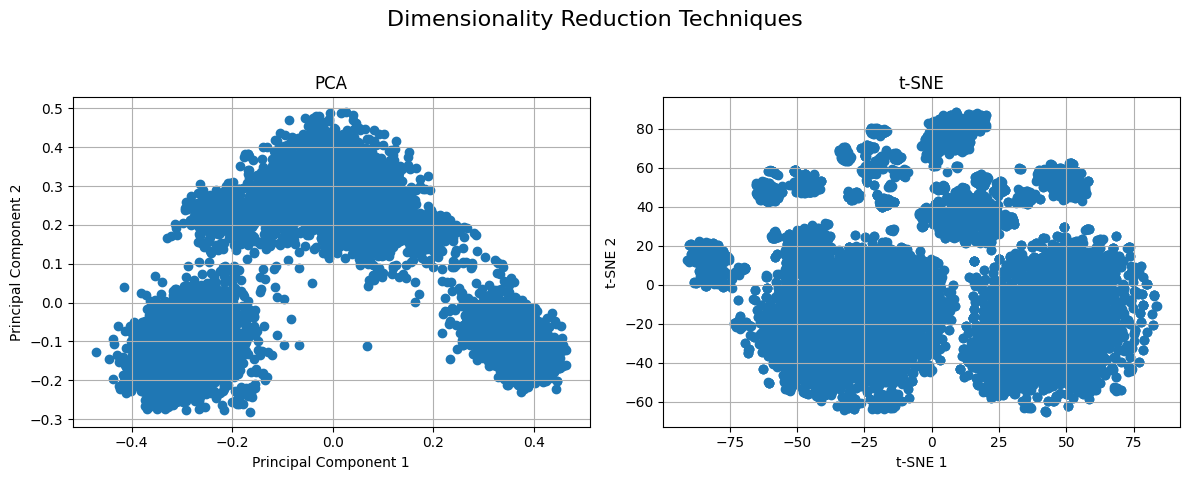

In [38]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# from umap import UMAP
import matplotlib.pyplot as plt

# Extract the embeddings from the DataFrame
embeddings = np.array(dx['embedding'].tolist())

# 2. Perform Dimensionality Reduction
# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

# t-SNE
tsne = TSNE(n_components=2)
tsne_result = tsne.fit_transform(embeddings)

# UMAP
# umap_reducer = UMAP(n_components=2)
# umap_result = umap_reducer.fit_transform(embeddings)

# 3. Visualize the Results
plt.figure(figsize=(12, 5))

# PCA Plot
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1])
plt.title('PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# t-SNE Plot
plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1])
plt.title('t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)

# UMAP Plot
# plt.subplot(1, 3, 3)
# plt.scatter(umap_result[:, 0], umap_result[:, 1])
# plt.title('UMAP')
# plt.xlabel('UMAP 1')
# plt.ylabel('UMAP 2')
# plt.grid(True)

plt.suptitle('Dimensionality Reduction Techniques', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig('dimensionality_reduction_plots.png')


Elbow plot has been saved as elbow_plot.png


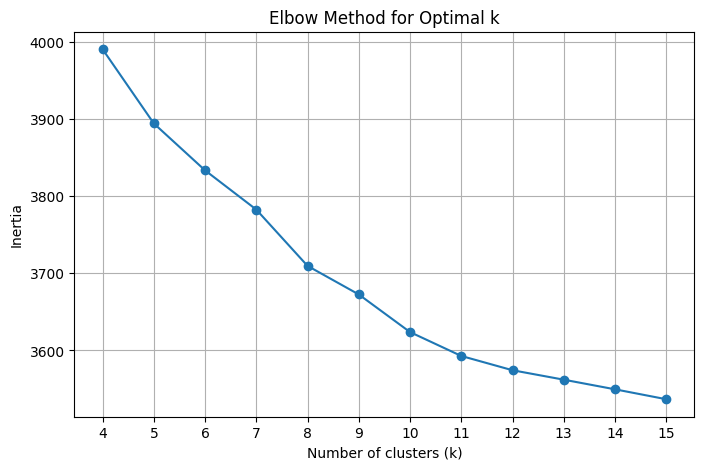

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from tqdm import tqdm


# Convert the 'embedding' column to a 2D numpy array for KMeans
X = np.array(dx['embedding'].tolist())

# --- Elbow Method Calculation ---
# We'll calculate the inertia for a range of k values
inertia = []
k_range = range(4, 16)  # Testing k from 1 to 10

for k in tqdm(k_range):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# --- Plotting the Elbow Curve ---
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('elbow_plot.png')

print("Elbow plot has been saved as elbow_plot.png")

